In [ ]:
# Exploratory Data Analysis

## Project Objective

# Notebook ini bertujuan mengeksplorasi karakteristik pelanggan FinanKu untuk menjawab business questions yang telah ditetapkan pada tahap Business Understanding.

# Analisis difokuskan pada:

# - Credit Risk Overview
# - Customer Profile
# - Geographic Analysis
# - Financial Analysis
# - Product Analysis
# - Customer Activity Analysis

import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [20]:
# Project
DATA_PATH = "../data/raw/FinanKu_Data_All.csv"

df = pd.read_csv(DATA_PATH)


In [21]:
# Average customer balance across four quarters
df["Avg Balance"] = (
    df[
        [
            "Balance Q1",
            "Balance Q2",
            "Balance Q3",
            "Balance Q4"
        ]
    ]
    .mean(axis=1)
)

In [ ]:
# Balance difference between the last and first quarter
df["Balance Change"] = (
    df["Balance Q4"] -
    df["Balance Q1"]
)

In [ ]:
# Average number of products owned
df["Avg Products"] = (
    df[
        [
            "NumOfProducts Q1",
            "NumOfProducts Q2",
            "NumOfProducts Q3",
            "NumOfProducts Q4"
        ]
    ]
    .mean(axis=1)
)

In [22]:
# Customer activity ratio during the observation period
df["Activity Rate"] = (
    df[
        [
            "ActiveMember Q1",
            "ActiveMember Q2",
            "ActiveMember Q3",
            "ActiveMember Q4"
        ]
    ]
    .mean(axis=1)
)

In [ ]:
new_features = [
    "Avg Balance",
    "Balance Change",
    "Avg Products",
    "Activity Rate"
]

display(df[new_features].head())

display(df[new_features].describe())

In [25]:
OUTPUT_PATH = "../data/processed/credit_risk_feature_engineered.csv"

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Dataset saved to:\n{OUTPUT_PATH}")

Dataset saved to:
../data/processed/credit_risk_feature_engineered.csv


In [28]:
df['Avg Balance'] = df[['Balance Q1', 'Balance Q2', 'Balance Q3', 'Balance Q4']].mean(axis=1)

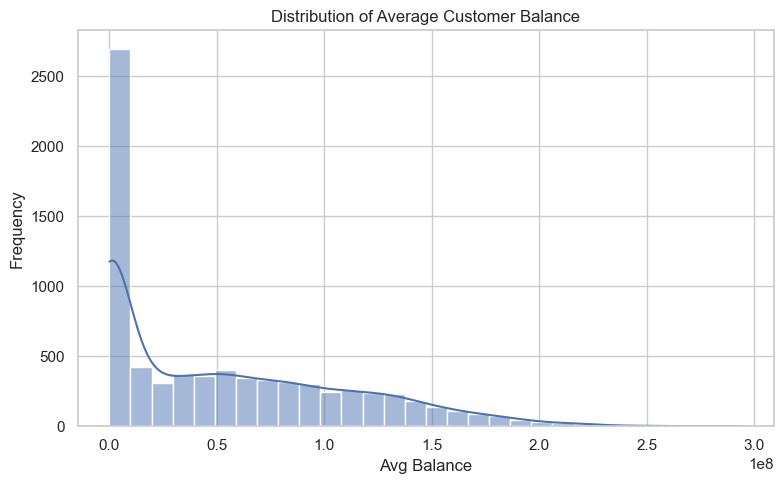

count         7,561.00
mean     53,261,745.68
std      55,875,717.97
min               0.00
25%         384,094.22
50%      38,631,563.63
75%      92,113,600.42
max     294,383,191.85
Name: Avg Balance, dtype: float64

In [ ]:
## 4.4 Financial Analysis

### Business Question

# Bagaimana distribusi rata-rata saldo pelanggan?
plot_histogram(
    data=df,
    column="Avg Balance",
    bins=30,
    title="Distribution of Average Customer Balance"
)

display(
    df["Avg Balance"].describe()
)

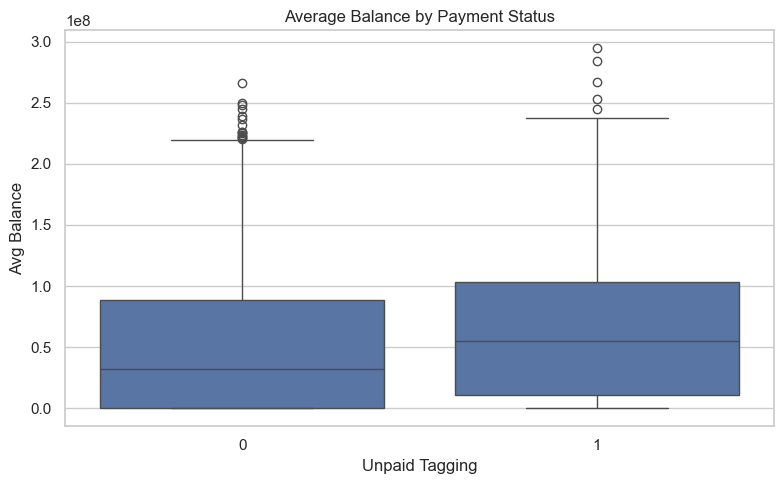

,count,mean,std,min,25%,50%,75%,max
Unpaid Tagging,,,,,,,,
0,"5,542.00","49,648,092.67","55,296,079.44",0.00,"295,574.28","32,015,654.14","88,291,521.24","265,719,253.40"
1,"2,019.00","63,180,945.76","56,269,694.06",0.00,"10,969,416.21","54,833,784.92","103,554,221.72","294,383,191.85"


In [ ]:
### Business Question

# Apakah rata-rata saldo pelanggan berhubungan dengan status unpaid?
plot_boxplot(
    data=df,
    x="Unpaid Tagging",
    y="Avg Balance",
    title="Average Balance by Payment Status"
)

display(
    df
    .groupby("Unpaid Tagging")["Avg Balance"]
    .describe()
)

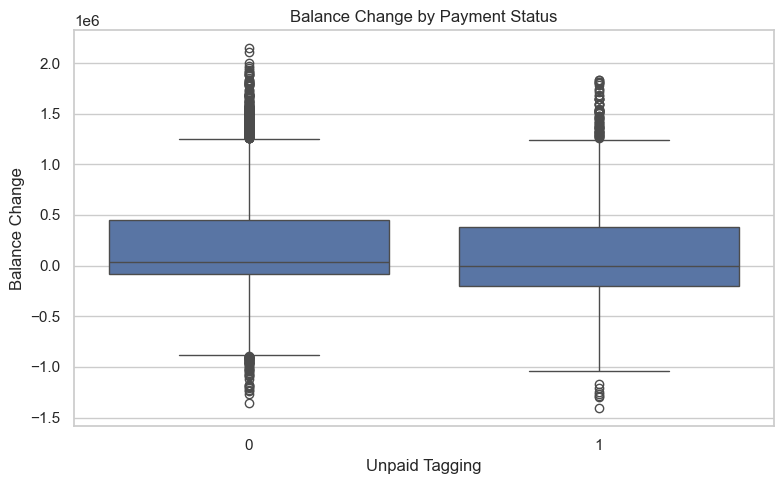

,count,mean,std,min,25%,50%,75%,max
Unpaid Tagging,,,,,,,,
0,"5,542.00","186,401.49","522,321.65","-1,358,853.00","-85,645.00","31,503.00","450,748.32","2,144,804.12"
1,"2,019.00","110,199.76","508,492.16","-1,408,684.00","-203,750.00",0.00,"381,385.00","1,836,902.72"


In [31]:
### Business Question

# Apakah perubahan saldo berkaitan dengan status unpaid?

df['Balance Change'] = df['Balance Q4'] - df['Balance Q1']

plot_boxplot(
    data=df,
    x="Unpaid Tagging",
    y="Balance Change",
    title="Balance Change by Payment Status"
)
display(
    df.groupby("Unpaid Tagging")["Balance Change"].describe()
)

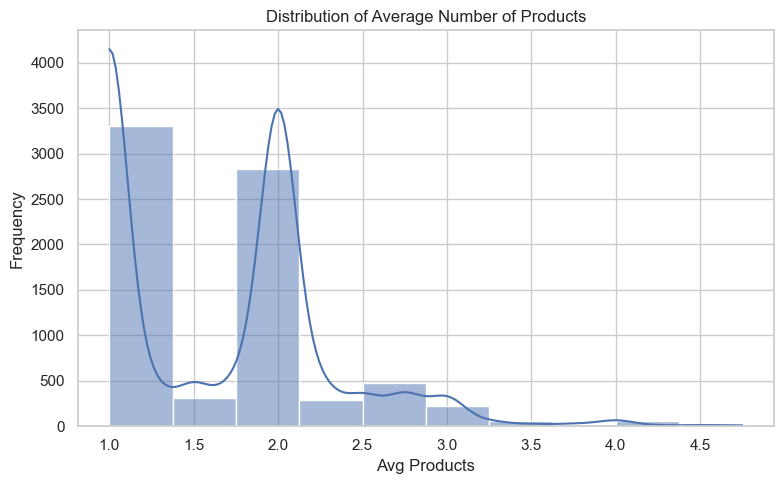

count   7,561.00
mean        1.65
std         0.66
min         1.00
25%         1.00
50%         1.75
75%         2.00
max         4.75
Name: Avg Products, dtype: float64

In [34]:
### Business Question

# Berapa rata-rata jumlah produk yang dimiliki pelanggan?
df['Avg Products'] = df[['NumOfProducts Q1', 'NumOfProducts Q2', 'NumOfProducts Q3', 'NumOfProducts Q4']].mean(axis=1)

plot_histogram(
    data=df,
    column="Avg Products",
    bins=10,
    title="Distribution of Average Number of Products"
)

display(
    df["Avg Products"].describe()
)

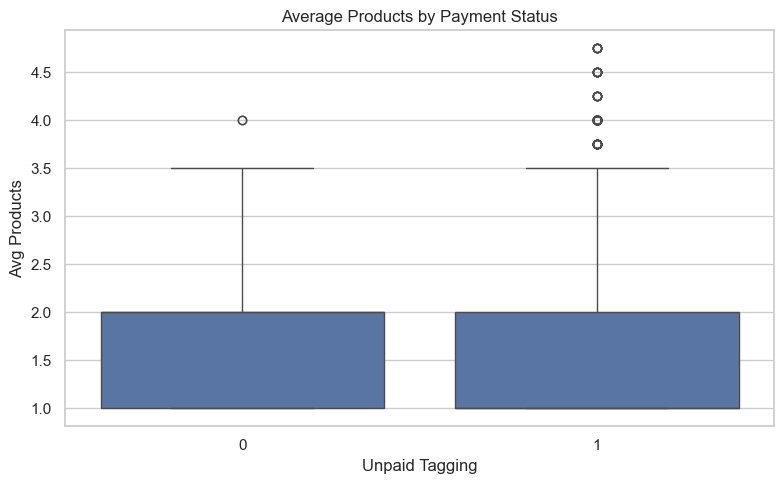

,count,mean,std,min,25%,50%,75%,max
Unpaid Tagging,,,,,,,,
0,"5,542.00",1.67,0.57,1.00,1.00,2.00,2.00,4.00
1,"2,019.00",1.61,0.85,1.00,1.00,1.00,2.00,4.75


In [35]:
### Business Question

# Apakah jumlah produk berhubungan dengan status unpaid?

df['Activity Rate'] = df[['ActiveMember Q1', 'ActiveMember Q2', 'ActiveMember Q3', 'ActiveMember Q4']].mean(axis=1)

plot_boxplot(
    data=df,
    x="Unpaid Tagging",
    y="Avg Products",
    title="Average Products by Payment Status"
)

display(
    df
    .groupby("Unpaid Tagging")["Avg Products"]
    .describe()
)

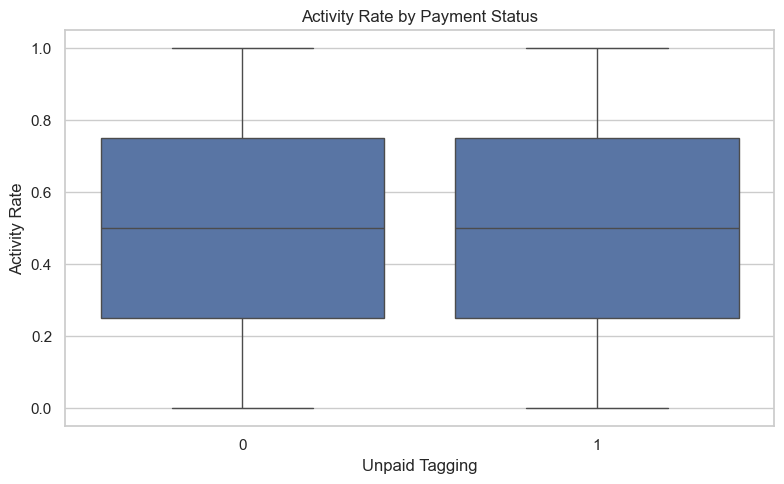

,count,mean,std,min,25%,50%,75%,max
Unpaid Tagging,,,,,,,,
0,"5,542.00",0.54,0.29,0.00,0.25,0.50,0.75,1.00
1,"2,019.00",0.52,0.28,0.00,0.25,0.50,0.75,1.00


In [ ]:
### Business Question

# Apakah aktivitas pelanggan berhubungan dengan status unpaid?
plot_boxplot(
    data=df,
    x="Unpaid Tagging",
    y="Activity Rate",
    title="Activity Rate by Payment Status"
)

display(
    df
    .groupby("Unpaid Tagging")["Activity Rate"]
    .describe()
)